In [1]:
import src.config as _sweep_config
_sweep_config.VALID_ASSET_DURATIONS_H = (0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0)
VALUATION_DURATION_H = 1.5
PHASE4_RUN_MODE = 'medium'
PHASE4_MODE_OVERRIDES = {}
print('Injected LSMC duration sweep: 1.5h')
print('Injected sweep scenario: cooptimised')
print('Injected Phase 4 run mode: medium')
print('Injected Phase 4 overrides:', PHASE4_MODE_OVERRIDES)


Injected LSMC duration sweep: 1.5h
Injected sweep scenario: cooptimised
Injected Phase 4 run mode: medium
Injected Phase 4 overrides: {}


# Phase 4: LSMC Valuation

LSMC backward induction on (SoC, SoH) grid; rolling-intrinsic LP benchmark; V_LSMC ? V_RI verification. This notebook is generated from `bess_valuation_full.ipynb` Phase 4 and can run independently from saved processed inputs.


In [2]:
import sys
from pathlib import Path

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = find_project_root(_ROOT_CANDIDATE)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [3]:
# Phase 4 bootstrap: load existing simulation bundle, or generate it once if missing.
# Use smaller paths/steps here for quick iteration; increase for production.
# Standalone Phase 4 defaults and imports.
import os
import time
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

from src.config import ASSET, DEGRADATION, FINANCE, LSMC as LSMC_CFG, SCHWARTZ_SMITH, configure_asset_duration
from src.optimisation.dispatch import enumerate_modes
from src.optimisation.lsmc import LSMCSolver, run_lsmc
from src.optimisation.rolling_intrinsic import rolling_intrinsic, rolling_intrinsic_parallel
from src.processes.ancillary import AncillaryParams
from src.processes.hpfc import HPFCParams
from src.processes.imbalance import ImbalanceParams
from src.processes.schwartz_smith import SSParams
from src.processes.simulate import default_params_from_config, simulate
from src.validation import summarize_action_distribution, validate_path_bundle

RAW = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

# Valuation duration selector: choose 1, 2, or 4 hours.
# Phase 4 must be rerun after changing this so the saved policy/result match the asset.
VALUATION_DURATION_H = float(globals().get('VALUATION_DURATION_H', 2.0))
configure_asset_duration(ASSET, VALUATION_DURATION_H)
DURATION_LABEL = f'{ASSET["duration_h"]:g}h'
print(f'Asset under valuation: {ASSET["power_mw"]:.0f} MW / {ASSET["energy_mwh"]:.0f} MWh ({ASSET["duration_h"]:.0f}h)')
print(f'Output label: {DURATION_LABEL}')

SEED = int(LSMC_CFG.get('seed', 42))
DT = float(LSMC_CFG.get('dt_hours', 0.5)) / 8760.0

# Switch between quick smoke, medium diagnostic, and yearly cached-bundle runs.
# Use 'medium' for diagnostic refreshes; set to 'full' before publishing artefacts.
PHASE4_RUN_MODE = globals().get('PHASE4_RUN_MODE', 'medium')  # 'partial', 'medium', or 'full'
PHASE4_RUNS = {
    'partial': {
        'ri_paths': 25,
        'bwd_paths': 250,
        'bwd_steps': 240,
        'fwd_paths': 250,
        'fwd_workers': 4,
        'ridge_alpha': 1.0,
        'n_soc_nodes': 9,
        'soh_nodes': [1.00, 0.90, 0.82],
        'net_levels': [-1.0, -0.5, 0.0, 0.5, 1.0],
        'dc_levels': [0.0, 0.5],
        'qr_levels': [0.0, 0.25],
    },
    'medium': {
        'ri_paths': 50,
        'bwd_paths': 500,
        'bwd_steps': 4320,  # 90 days of half-hours
        'fwd_paths': 1000,
        'fwd_workers': 6,
        'ridge_alpha': 1.0,
        'n_soc_nodes': 9,
        'soh_nodes': [1.00, 0.90, 0.82],
        'net_levels': [-1.0, -0.5, 0.0, 0.5, 1.0],
        'dc_levels': [0.0, 0.5],
        'qr_levels': [0.0, 0.25],
    },
    'full': {
        'ri_paths': 100,
        'bwd_paths': None,   # None = all cached paths
        'bwd_steps': None,   # None = full cached horizon
        'fwd_paths': None,   # None = all cached paths
        'fwd_workers': 8,
        'ridge_alpha': None,  # None = use src.config.LSMC default
        'n_soc_nodes': 9,
        'soh_nodes': [1.00, 0.90, 0.82],
        'net_levels': [-1.0, -0.5, 0.0, 0.5, 1.0],
        'dc_levels': [0.0, 0.5],
        'qr_levels': [0.0, 0.25],
    },
}
if PHASE4_RUN_MODE not in PHASE4_RUNS:
    raise ValueError(f'Unknown PHASE4_RUN_MODE: {PHASE4_RUN_MODE}')
PHASE4_RUN = dict(PHASE4_RUNS[PHASE4_RUN_MODE])
PHASE4_MODE_OVERRIDES = globals().get('PHASE4_MODE_OVERRIDES', {})
if PHASE4_MODE_OVERRIDES:
    PHASE4_RUN.update(PHASE4_MODE_OVERRIDES)
    print(f'Applied Phase 4 run overrides: {PHASE4_MODE_OVERRIDES}')
print(f'Phase 4 run mode: {PHASE4_RUN_MODE}')

# Defaults only apply when the cached bundle is missing.
N_PATHS = int(LSMC_CFG.get('n_paths', 1000))
N_STEPS = 365 * 48

SIM_BUNDLE_PATH = PROCESSED / 'sim_bundle.pkl'
GENERATE_BUNDLE_IF_MISSING = True
BUNDLE_PATHS = min(int(PHASE4_RUN.get('bwd_paths') or N_PATHS), N_PATHS)
BUNDLE_STEPS = int(PHASE4_RUN.get('bwd_steps') or N_STEPS)


def _load_json_or_default(cls, default_obj, *fnames):
    for fname in fnames:
        p = PROCESSED / fname
        if p.exists():
            print(f'  Loaded calibrated {fname}')
            return cls.from_json(p)
    print(f'  Using config default for {" or ".join(fnames)}')
    return default_obj


ss_def, hpfc_def, imb_def, anc_def = default_params_from_config()
ss_p = _load_json_or_default(SSParams, ss_def, 'ss_params.json')
hpfc_p = _load_json_or_default(HPFCParams, hpfc_def, 'pca_params.json', 'hpfc_params.json')
imb_p = _load_json_or_default(ImbalanceParams, imb_def, 'imbalance_params.json')
anc_p = _load_json_or_default(AncillaryParams, anc_def, 'ancillary_params.json')


if SIM_BUNDLE_PATH.exists():
    print(f'Loading cached simulation bundle: {SIM_BUNDLE_PATH}')
    with open(SIM_BUNDLE_PATH, 'rb') as f:
        bundle = pickle.load(f)
else:
    if not GENERATE_BUNDLE_IF_MISSING:
        raise FileNotFoundError(f'Missing {SIM_BUNDLE_PATH}')

    print(f'Generating simulation bundle: {BUNDLE_PATHS:,} paths x {BUNDLE_STEPS:,} steps')
    from src.config import SCHWARTZ_SMITH
    xi_init = np.full(BUNDLE_PATHS, np.log(SCHWARTZ_SMITH['forward_anchor_gbp_mwh']))
    bundle = simulate(
        ss_p, hpfc_p, imb_p, anc_p,
        n_paths=BUNDLE_PATHS, n_steps=BUNDLE_STEPS,
        dt=DT, seed=SEED, xi_0=xi_init,
    )
    with open(SIM_BUNDLE_PATH, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved simulation bundle: {SIM_BUNDLE_PATH}')

N_PATHS = int(bundle.n_paths)
N_STEPS = int(bundle.n_steps)
DT = float(bundle.dt)
RUN_STEPS = min(int(PHASE4_RUN['bwd_steps'] or bundle.n_steps), bundle.n_steps)
RUN_BWD_PATHS = min(int(PHASE4_RUN['bwd_paths'] or bundle.n_paths), bundle.n_paths)
RUN_FWD_PATHS = min(int(PHASE4_RUN['fwd_paths'] or bundle.n_paths), bundle.n_paths)
print(f'bundle: {bundle.n_paths:,} paths x {bundle.n_steps:,} steps')
print(f'selected run: {RUN_BWD_PATHS:,} backward paths x {RUN_STEPS:,} steps; {RUN_FWD_PATHS:,} forward paths')
bundle_check = validate_path_bundle(bundle, forward_anchor_gbp_mwh=SCHWARTZ_SMITH['forward_anchor_gbp_mwh'])
bundle_check.raise_if_failed()
print(bundle_check.summary())


Asset under valuation: 100 MW / 150 MWh (2h)
Output label: 1.5h
Phase 4 run mode: medium
  Loaded calibrated ss_params.json
  Loaded calibrated pca_params.json
  Loaded calibrated imbalance_params.json
  Loaded calibrated ancillary_params.json
Loading cached simulation bundle: G:\My Drive\Research\bess_project\data\processed\sim_bundle.pkl


bundle: 1,000 paths x 17,520 steps
selected run: 500 backward paths x 4,320 steps; 1,000 forward paths


path_bundle: PASS


## 1  Simulate joint paths

In [4]:
from src.config import SCHWARTZ_SMITH
xi_init = np.full(bundle.n_paths, np.log(SCHWARTZ_SMITH["forward_anchor_gbp_mwh"]))
if not np.allclose(bundle.xi[:, 0], xi_init, atol=0.01):
    print("WARNING: cached bundle has xi_0 near zero; regenerate for accurate pricing.")

# Diagnostic ? uses clipped exp to match what LSMC actually sees
import numpy as np
P_da_mat = np.exp(np.clip(bundle.ln_P_base, -100.0, np.log(500.0)))
print(f"P_da  ? mean: {P_da_mat.mean():.1f}  std: {P_da_mat.std():.1f}  "
      f"P5/P95: {np.percentile(P_da_mat[:,-1],[5,95])} ?/MWh")
print(f"delta ? mean: {bundle.delta_imb.mean():.1f}  std: {bundle.delta_imb.std():.1f}  ?/MWh")
print(f'pi_DC ? mean: {bundle.pi["DC_Low"].mean():.2f}  ?/MW/h')


P_da  ? mean: 97.3  std: 69.8  P5/P95: [ 23.8598989  264.40248252] ?/MWh
delta ? mean: -20.6  std: 140.0  ?/MWh
pi_DC ? mean: 5.24  ?/MW/h


## 2  Rolling intrinsic benchmark

In [5]:
# Rolling intrinsic is expensive: it solves many LPs per path.
# Use path-level multiprocessing for the sampled benchmark; increase RI_N_PATHS for production checks.
RI_N_PATHS = min(int(PHASE4_RUN['ri_paths']), P_da_mat.shape[0])
RI_WORKERS = max(1, min(8, (os.cpu_count() or 2) - 1, RI_N_PATHS))
rng_ri = np.random.default_rng(SEED)
ri_idx = rng_ri.choice(P_da_mat.shape[0], size=RI_N_PATHS, replace=False)
P_da_ri = np.clip(P_da_mat[ri_idx, :RUN_STEPS], -100.0, 500.0).astype(np.float32)

print(f'Running rolling intrinsic on {RI_N_PATHS:,} sampled paths out of {P_da_mat.shape[0]:,} using {RI_WORKERS} workers')

t0 = time.time()
try:
    pv_ri, soc_ri = rolling_intrinsic_parallel(
        P_da_ri,
        ASSET, LSMC_CFG, FINANCE,
        E_init_frac=0.5, window_hh=48, gate_hh=8,
        max_workers=RI_WORKERS, backend='thread', verbose=True,
    )
except Exception as exc:
    print(f'Parallel RI failed ({exc}); falling back to serial')
    pv_ri, soc_ri = rolling_intrinsic(
        P_da_ri,
        ASSET, LSMC_CFG, FINANCE,
        E_init_frac=0.5, window_hh=48, gate_hh=8, verbose=True,
    )

ri_time = time.time() - t0
print(f'\nRI complete in {ri_time:.1f}s')
print(f'V_RI  P5/P50/P95: GBP{np.percentile(pv_ri,5):,.0f} / GBP{np.percentile(pv_ri,50):,.0f} / GBP{np.percentile(pv_ri,95):,.0f}')
print(f'V_RI  per MW: GBP{pv_ri.mean() / ASSET["power_mw"]:,.0f} / MW')


Running rolling intrinsic on 50 sampled paths out of 1,000 using 8 workers


  RI paths complete 50/50 ...

RI complete in 149.2s
V_RI  P5/P50/P95: GBP15,845 / GBP32,027 / GBP46,827
V_RI  per MW: GBP323 / MW


## 3  LSMC backward induction

In [6]:
from src.processes.simulate import PathBundle

# Interactive LSMC settings. Full grid is much slower:
# 21 SoC x 5 SoH x 36 modes x 1,000 paths.
LSMC_BWD_PATHS = RUN_BWD_PATHS
LSMC_BWD_STEPS = RUN_STEPS
LSMC_FAST_CFG = dict(LSMC_CFG)
LSMC_FAST_CFG.update({
    'n_soc_nodes': int(PHASE4_RUN['n_soc_nodes']),
    'soh_nodes': PHASE4_RUN['soh_nodes'],
    'n_soh_nodes': len(PHASE4_RUN['soh_nodes']),
})
if PHASE4_RUN.get('ridge_alpha') is not None:
    LSMC_FAST_CFG['ridge_alpha'] = float(PHASE4_RUN['ridge_alpha'])
FAST_MODES = enumerate_modes(
    net_levels=PHASE4_RUN['net_levels'],
    dc_levels=PHASE4_RUN['dc_levels'],
    qr_levels=PHASE4_RUN['qr_levels'],
)

rng_lsmc = np.random.default_rng(SEED)
bwd_idx = rng_lsmc.choice(bundle.n_paths, size=LSMC_BWD_PATHS, replace=False)
bundle_bwd = PathBundle(
    chi=bundle.chi[bwd_idx, :LSMC_BWD_STEPS + 1],
    xi=bundle.xi[bwd_idx, :LSMC_BWD_STEPS + 1],
    ln_P_base=bundle.ln_P_base[bwd_idx, :LSMC_BWD_STEPS + 1],
    lam=bundle.lam[bwd_idx, :LSMC_BWD_STEPS + 1, :],
    delta_imb=bundle.delta_imb[bwd_idx, :LSMC_BWD_STEPS + 1],
    pi={k: v[bwd_idx, :LSMC_BWD_STEPS + 1] for k, v in bundle.pi.items()},
    dt=bundle.dt,
    n_paths=LSMC_BWD_PATHS,
    n_steps=LSMC_BWD_STEPS,
)

if 'hpfc_p' not in globals():
    _, hpfc_def, _, _ = default_params_from_config()
    if '_load_json_or_default' in globals():
        hpfc_p = _load_json_or_default(HPFCParams, hpfc_def, 'pca_params.json', 'hpfc_params.json')
    else:
        hpfc_p = hpfc_def
    print('hpfc_p was not initialized; using HPFC params for LSMC basis features.')

solver = LSMCSolver(
    ASSET, LSMC_FAST_CFG, DEGRADATION, FINANCE,
    modes=FAST_MODES, verbose=True, hpfc_params=hpfc_p,
)
print(f'Backward sample: {LSMC_BWD_PATHS:,} paths x {LSMC_BWD_STEPS:,} steps from cached {bundle.n_paths:,} x {bundle.n_steps:,}')
print(f'SoC grid: {solver.soc_grid.tolist()}')
print(f'SoH nodes: {solver.soh_nodes.tolist()}')
print(f'Modes: {len(FAST_MODES)}')
print(f'Discount per HH: {solver.disc:.8f}')

t0 = time.time()
policy = solver.backward(bundle_bwd)
bwd_time = time.time() - t0

print(f'\nBackward pass: {bwd_time:.1f}s')
print(f'beta shape: {policy.beta.shape}')
print(f'beta NaN:   {np.isnan(policy.beta).any()}')
print(f'beta range: [{policy.beta.min():.3f}, {policy.beta.max():.3f}]')


Backward sample: 500 paths x 4,320 steps from cached 1,000 x 17,520
SoC grid: [15.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0, 135.0]
SoH nodes: [1.0, 0.8999999761581421, 0.8199999928474426]
Modes: 12
Discount per HH: 0.99999486
LSMC backward: T=4320 steps, N=500 paths, J=9 SoC nodes, K=3 SoH nodes, M=12 modes


  t=    0 / 4320  ...
  Backward pass complete. beta shape: (4320, 9, 3, 14)
  LSMC diagnostics: beta_abs_max=6.94e+06, sample_cond_max=2.15e+03, rank_def=0/207

Backward pass: 103.2s
beta shape: (4320, 9, 3, 14)
beta NaN:   False
beta range: [-6942101.500, 4943986.500]


## 4  Forward simulation — MTM distribution

In [7]:
# Forward simulation using the selected run-mode path sample.
FWD_N_PATHS = RUN_FWD_PATHS
FWD_N_STEPS = min(policy.n_steps, bundle.n_steps)
FWD_WORKERS = max(1, min(int(PHASE4_RUN['fwd_workers']), (os.cpu_count() or 2) - 1, FWD_N_PATHS))
rng_fwd = np.random.default_rng(SEED + 1)
fwd_idx = rng_fwd.choice(bundle.n_paths, size=FWD_N_PATHS, replace=False)
bundle_fwd = PathBundle(
    chi=bundle.chi[fwd_idx, :FWD_N_STEPS + 1],
    xi=bundle.xi[fwd_idx, :FWD_N_STEPS + 1],
    ln_P_base=bundle.ln_P_base[fwd_idx, :FWD_N_STEPS + 1],
    lam=bundle.lam[fwd_idx, :FWD_N_STEPS + 1, :],
    delta_imb=bundle.delta_imb[fwd_idx, :FWD_N_STEPS + 1],
    pi={k: v[fwd_idx, :FWD_N_STEPS + 1] for k, v in bundle.pi.items()},
    dt=bundle.dt,
    n_paths=FWD_N_PATHS,
    n_steps=FWD_N_STEPS,
)

print(f'Forward simulation on {FWD_N_PATHS:,} paths x {FWD_N_STEPS:,} steps out of cached {bundle.n_paths:,} x {bundle.n_steps:,} using {FWD_WORKERS} workers')

t0 = time.time()
# The solver clips extreme simulated prices internally for numerical stability.
try:
    result = solver.forward_parallel(bundle_fwd, policy, max_workers=FWD_WORKERS)
except Exception as exc:
    print(f'Parallel forward failed ({exc}); falling back to serial')
    result = solver.forward(bundle_fwd, policy)
fwd_time = time.time() - t0
N_PATHS = int(result.pv_paths.shape[0])
N_STEPS = int(result.cashflow_paths.shape[1])

print(f'Forward pass: {fwd_time:.1f}s')
print()
print(f'MTM mean:      GBP{result.mtm_mean:>12,.0f}')
print(f'MTM std:       GBP{result.mtm_std:>12,.0f}')
print(f'MTM P5:        GBP{result.mtm_p5:>12,.0f}')
print(f'MTM P95:       GBP{result.mtm_p95:>12,.0f}')
print()
print(f'Per MW (mean): GBP{result.mtm_mean / ASSET["power_mw"]:>12,.0f} / MW')
print(f'Per MW (P50):  GBP{np.median(result.pv_paths) / ASSET["power_mw"]:>12,.0f} / MW')

RESULT_PATH = PROCESSED / f'lsmc_valuation_result_{DURATION_LABEL}.pkl'
POLICY_PATH = PROCESSED / f'lsmc_policy_{DURATION_LABEL}.pkl'
with open(RESULT_PATH, 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(POLICY_PATH, 'wb') as f:
    pickle.dump(policy, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f'Saved valuation result: {RESULT_PATH}')
print(f'Saved policy:           {POLICY_PATH}')


Forward simulation on 1,000 paths x 4,320 steps out of cached 1,000 x 17,520 using 6 workers


  Forward chunks complete 0/6 after 10s ...


  Forward chunks complete 0/6 after 20s ...


  Forward chunks complete 0/6 after 30s ...


  Forward chunks complete 1/6 after 32s ...


...

  Forward chunks complete 4/6 after 32s ...


  Forward chunks complete 5/6 after 32s ...


  Forward chunks complete 6/6 after 32s ...


Forward pass: 32.1s

MTM mean:      GBP     597,882
MTM std:       GBP     301,004
MTM P5:        GBP     250,982
MTM P95:       GBP   1,182,938

Per MW (mean): GBP       5,979 / MW
Per MW (P50):  GBP       5,277 / MW


Saved valuation result: G:\My Drive\Research\bess_project\data\processed\lsmc_valuation_result_1.5h.pkl
Saved policy:           G:\My Drive\Research\bess_project\data\processed\lsmc_policy_1.5h.pkl


## 5  V_LSMC ≥ V_RI validation

In [8]:
lsmc_mean = result.mtm_mean
ri_mean   = float(pv_ri.mean())
ratio     = lsmc_mean / ri_mean if ri_mean > 0 else float('inf')
valuation_horizon_years = FWD_N_STEPS * float(LSMC_CFG.get('dt_hours', 0.5)) / 8760.0
annualization_factor = 1.0 / valuation_horizon_years if valuation_horizon_years > 0 else float('nan')
lsmc_mean_annual = lsmc_mean * annualization_factor
ri_mean_annual = ri_mean * annualization_factor
lsmc_per_mw_year = lsmc_mean_annual / ASSET['power_mw']
ri_per_mw_year = ri_mean_annual / ASSET['power_mw']
pv_ri_annual = pv_ri * annualization_factor
pv_lsmc_annual = result.pv_paths * annualization_factor

print(f'Run horizon: {valuation_horizon_years:.3f} years ({FWD_N_STEPS:,} half-hours)')
print(f'Annualization factor: {annualization_factor:.2f}x')
print(f'V_LSMC mean annualized: £{lsmc_mean_annual:,.0f}/yr  |  £{lsmc_per_mw_year:,.0f}/MW/yr')
print(f'V_RI   mean annualized: £{ri_mean_annual:,.0f}/yr  |  £{ri_per_mw_year:,.0f}/MW/yr')
print(f'Raw horizon V_LSMC: £{lsmc_mean:,.0f}; raw horizon V_RI: £{ri_mean:,.0f}')
print(f'Ratio V_LSMC / V_RI: {ratio:.2f}x')

if lsmc_mean >= ri_mean * 0.95:
    print('✓  V_LSMC ≥ V_RI  (LSMC stochastic value exceeds deterministic benchmark)')
else:
    print('✗  WARNING: V_LSMC < V_RI — backward pass may need more SoC nodes or paths')

Run horizon: 0.247 years (4,320 half-hours)
Annualization factor: 4.06x
V_LSMC mean annualized: £2,424,745/yr  |  £24,247/MW/yr
V_RI   mean annualized: £130,956/yr  |  £1,310/MW/yr
Raw horizon V_LSMC: £597,882; raw horizon V_RI: £32,291
Ratio V_LSMC / V_RI: 18.52x
✓  V_LSMC ≥ V_RI  (LSMC stochastic value exceeds deterministic benchmark)


## 6  Visualisations

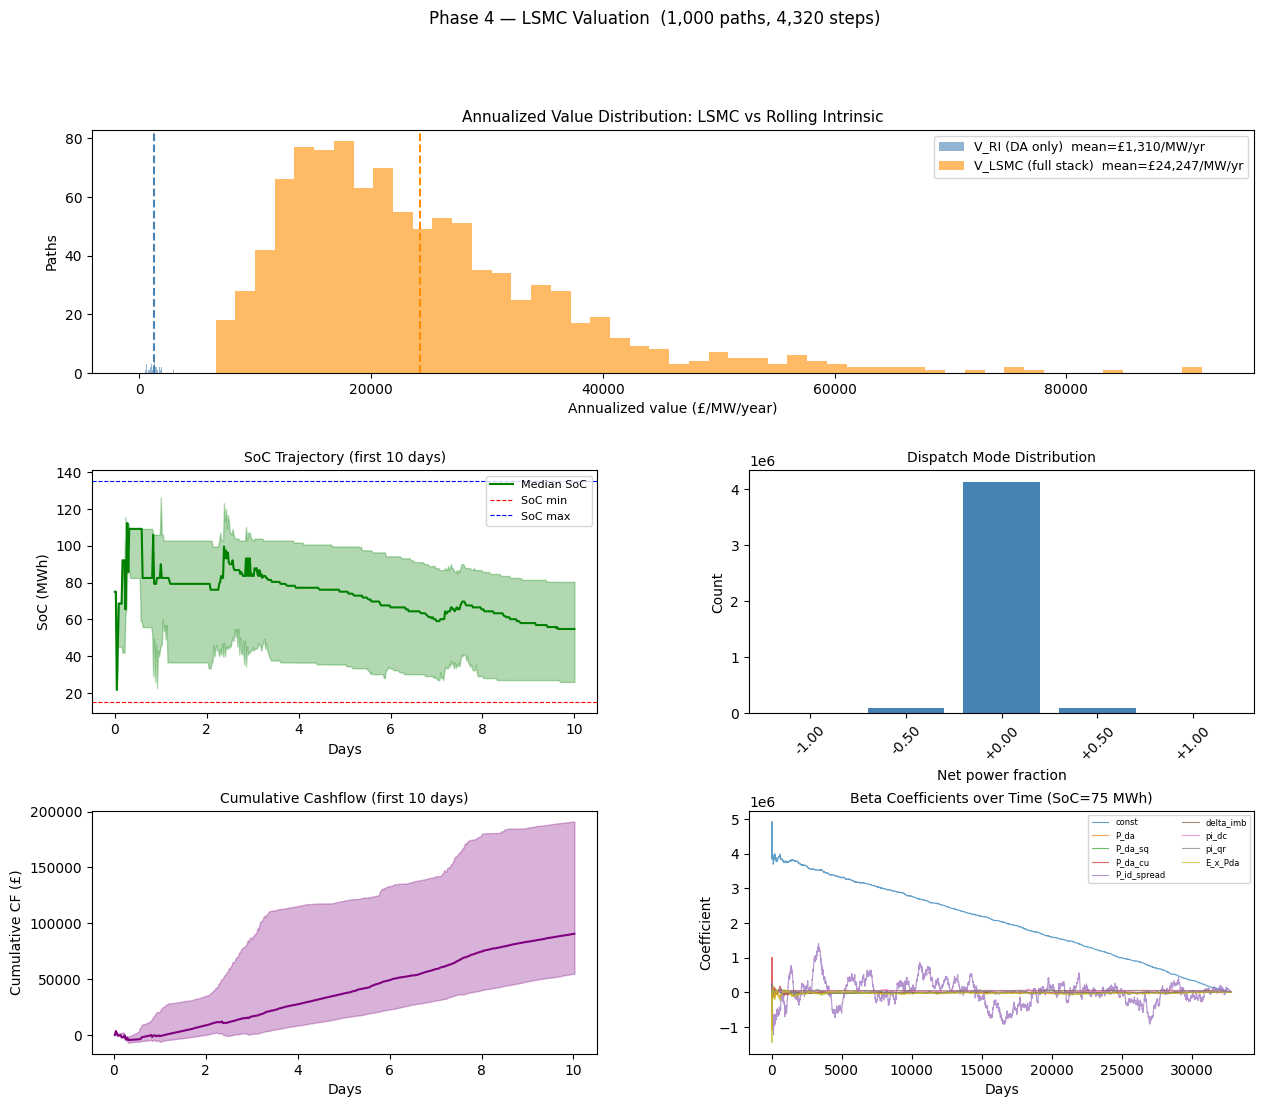

In [9]:
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

# 1. PV distribution — LSMC vs RI
ax1 = fig.add_subplot(gs[0, :])
bins = 50
ax1.hist(pv_ri_annual / ASSET['power_mw'], bins=bins, alpha=0.6, color='steelblue', label=f'V_RI (DA only)  mean=£{ri_per_mw_year:,.0f}/MW/yr')
ax1.hist(pv_lsmc_annual / ASSET['power_mw'], bins=bins, alpha=0.6, color='darkorange', label=f'V_LSMC (full stack)  mean=£{lsmc_per_mw_year:,.0f}/MW/yr')
ax1.axvline(ri_per_mw_year,   color='steelblue',  linestyle='--', linewidth=1.5)
ax1.axvline(lsmc_per_mw_year, color='darkorange', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Annualized value (£/MW/year)'); ax1.set_ylabel('Paths')
ax1.set_title('Annualized Value Distribution: LSMC vs Rolling Intrinsic', fontsize=11)
ax1.legend(fontsize=9)

# 2. SoC trajectory — percentile fan
ax2 = fig.add_subplot(gs[1, 0])
t_axis = np.arange(N_STEPS + 1) * DT * 365
t_show = t_axis[:481]  # first 10 days
q10, q50, q90 = np.percentile(result.soc_paths[:, :481], [10, 50, 90], axis=0)
ax2.fill_between(t_show, q10, q90, alpha=0.3, color='green')
ax2.plot(t_show, q50, color='green', linewidth=1.5, label='Median SoC')
ax2.axhline(ASSET['soc_min_mwh'], color='red',  linewidth=0.8, linestyle='--', label='SoC min')
ax2.axhline(ASSET['soc_max_mwh'], color='blue', linewidth=0.8, linestyle='--', label='SoC max')
ax2.set_xlabel('Days'); ax2.set_ylabel('SoC (MWh)')
ax2.set_title('SoC Trajectory (first 10 days)', fontsize=10)
ax2.legend(fontsize=8)

# 3. Action distribution across modes
ax3 = fig.add_subplot(gs[1, 1])
mode_counts = np.bincount(result.action_paths.ravel(), minlength=len(policy.modes))
mode_labels = [f'{m.net_frac:+.2f}' for m in policy.modes]
# Aggregate by net_frac
net_fracs_unique = sorted(set(m.net_frac for m in policy.modes))
net_counts = {}
for nf in net_fracs_unique:
    idxs = [i for i, m in enumerate(policy.modes) if m.net_frac == nf]
    net_counts[nf] = sum(mode_counts[i] for i in idxs)
ax3.bar([f'{k:+.2f}' for k in net_counts], list(net_counts.values()), color='steelblue')
ax3.set_xlabel('Net power fraction'); ax3.set_ylabel('Count')
ax3.set_title('Dispatch Mode Distribution', fontsize=10)
ax3.tick_params(axis='x', rotation=45)

# 4. Cumulative cashflow percentile fan
ax4 = fig.add_subplot(gs[2, 0])
cum_cf = result.cashflow_paths.cumsum(axis=1)
t_cf = np.arange(1, N_STEPS + 1) * DT * 365
show = slice(None, 481)  # first 10 days
q10c, q50c, q90c = np.percentile(cum_cf[:, show], [10, 50, 90], axis=0)
ax4.fill_between(t_cf[show], q10c, q90c, alpha=0.3, color='purple')
ax4.plot(t_cf[show], q50c, color='purple', linewidth=1.5)
ax4.set_xlabel('Days'); ax4.set_ylabel('Cumulative CF (£)')
ax4.set_title('Cumulative Cashflow (first 10 days)', fontsize=10)

# 5. Learned beta coefficients for mid-horizon, mid-SoC node
ax5 = fig.add_subplot(gs[2, 1])
from src.optimisation.lsmc import BASIS_NAMES, N_BASIS
j_mid = len(solver.soc_grid) // 2
k_mid = 0
beta_t = policy.beta[:, j_mid, k_mid, :]   # (T, 14)
for feat_idx in range(N_BASIS):
    if abs(beta_t[:, feat_idx]).mean() > 0.01:
        ax5.plot(t_axis[:-1] * 365, beta_t[:, feat_idx],
                 alpha=0.7, linewidth=0.8, label=BASIS_NAMES[feat_idx])
ax5.set_xlabel('Days'); ax5.set_ylabel('Coefficient')
ax5.set_title(f'Beta Coefficients over Time (SoC={solver.soc_grid[j_mid]:.0f} MWh)', fontsize=10)
ax5.legend(fontsize=6, ncol=2)

plt.suptitle(f'Phase 4 — LSMC Valuation  ({N_PATHS:,} paths, {N_STEPS:,} steps)', fontsize=12)
plt.savefig(PROCESSED / f'lsmc_valuation_{DURATION_LABEL}.png', dpi=120, bbox_inches='tight')
plt.show()

## 7  Save results

In [10]:
import json

valuation_summary = {
    'run_mode':            PHASE4_RUN_MODE,
    'n_paths':             FWD_N_PATHS,
    'n_steps':             FWD_N_STEPS,
    'valuation_horizon_years': round(valuation_horizon_years, 6),
    'annualization_factor': round(annualization_factor, 6),
    'asset_mw':            ASSET['power_mw'],
    'asset_mwh':           ASSET['energy_mwh'],
    'duration_h':          ASSET['duration_h'],
    'duration_label':      DURATION_LABEL,
    'mtm_gbp_horizon': {
        'mean': round(result.mtm_mean),
        'std':  round(result.mtm_std),
        'p5':   round(result.mtm_p5),
        'p50':  round(float(np.median(result.pv_paths))),
        'p95':  round(result.mtm_p95),
    },
    'mtm_gbp_annualized': {
        'mean': round(result.mtm_mean * annualization_factor),
        'std':  round(result.mtm_std * annualization_factor),
        'p5':   round(result.mtm_p5 * annualization_factor),
        'p50':  round(float(np.median(result.pv_paths)) * annualization_factor),
        'p95':  round(result.mtm_p95 * annualization_factor),
    },
    'mtm_gbp_per_mw_horizon': {
        'mean': round(result.mtm_mean / ASSET['power_mw']),
        'p50':  round(float(np.median(result.pv_paths)) / ASSET['power_mw']),
    },
    'mtm_gbp_per_mw_year': {
        'mean': round(lsmc_per_mw_year),
        'std':  round(result.mtm_std * annualization_factor / ASSET['power_mw']),
        'p5':   round(result.mtm_p5 * annualization_factor / ASSET['power_mw']),
        'p50':  round(float(np.median(result.pv_paths)) * annualization_factor / ASSET['power_mw']),
        'p95':  round(result.mtm_p95 * annualization_factor / ASSET['power_mw']),
    },
    'ri_mean_gbp':         round(ri_mean),
    'ri_mean_gbp_annualized': round(ri_mean_annual),
    'ri_mean_gbp_per_mw_year': round(ri_per_mw_year),
    'lsmc_ri_ratio':       round(ratio, 3),
    'v_lsmc_gte_v_ri':     bool(lsmc_mean >= ri_mean * 0.95),
    'bwd_time_s':          round(bwd_time, 1),
    'fwd_time_s':          round(fwd_time, 1),
    'action_distribution': summarize_action_distribution(result.action_paths, policy.modes, result.cashflow_paths),
    'action_q_diagnostics': getattr(result, 'action_diagnostics', {}),
    'lsmc_diagnostics': {
        k: (float(v) if isinstance(v, (int, float, np.integer, np.floating)) else v)
        for k, v in getattr(policy, 'diagnostics', {}).items()
    },
}

out = PROCESSED / f'lsmc_valuation_summary_{DURATION_LABEL}.json'
with open(out, 'w') as f:
    json.dump(valuation_summary, f, indent=2)
print(f'Saved: {out}')
print(json.dumps(valuation_summary, indent=2))

Saved: G:\My Drive\Research\bess_project\data\processed\lsmc_valuation_summary_1.5h.json
{
  "run_mode": "medium",
  "n_paths": 1000,
  "n_steps": 4320,
  "valuation_horizon_years": 0.246575,
  "annualization_factor": 4.055556,
  "asset_mw": 100.0,
  "asset_mwh": 150.0,
  "duration_h": 1.5,
  "duration_label": "1.5h",
  "mtm_gbp_horizon": {
    "mean": 597882,
    "std": 301004,
    "p5": 250982,
    "p50": 527677,
    "p95": 1182938
  },
  "mtm_gbp_annualized": {
    "mean": 2424745,
    "std": 1220737,
    "p5": 1017873,
    "p50": 2140024,
    "p95": 4797471
  },
  "mtm_gbp_per_mw_horizon": {
    "mean": 5979,
    "p50": 5277
  },
  "mtm_gbp_per_mw_year": {
    "mean": 24247,
    "std": 12207,
    "p5": 10179,
    "p50": 21400,
    "p95": 47975
  },
  "ri_mean_gbp": 32291,
  "ri_mean_gbp_annualized": 130956,
  "ri_mean_gbp_per_mw_year": 1310,
  "lsmc_ri_ratio": 18.516,
  "v_lsmc_gte_v_ri": true,
  "bwd_time_s": 103.2,
  "fwd_time_s": 32.1,
  "action_distribution": {
    "total_decis